In [1]:
#!pip install pandas-ta
from My_functions import *

In [2]:
symbol = "AAPL"
start_date = "2025-05-8"
end_date = "2025-05-15"
timeframe_unit: str = "Minute"
multiplier: int = 1
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)


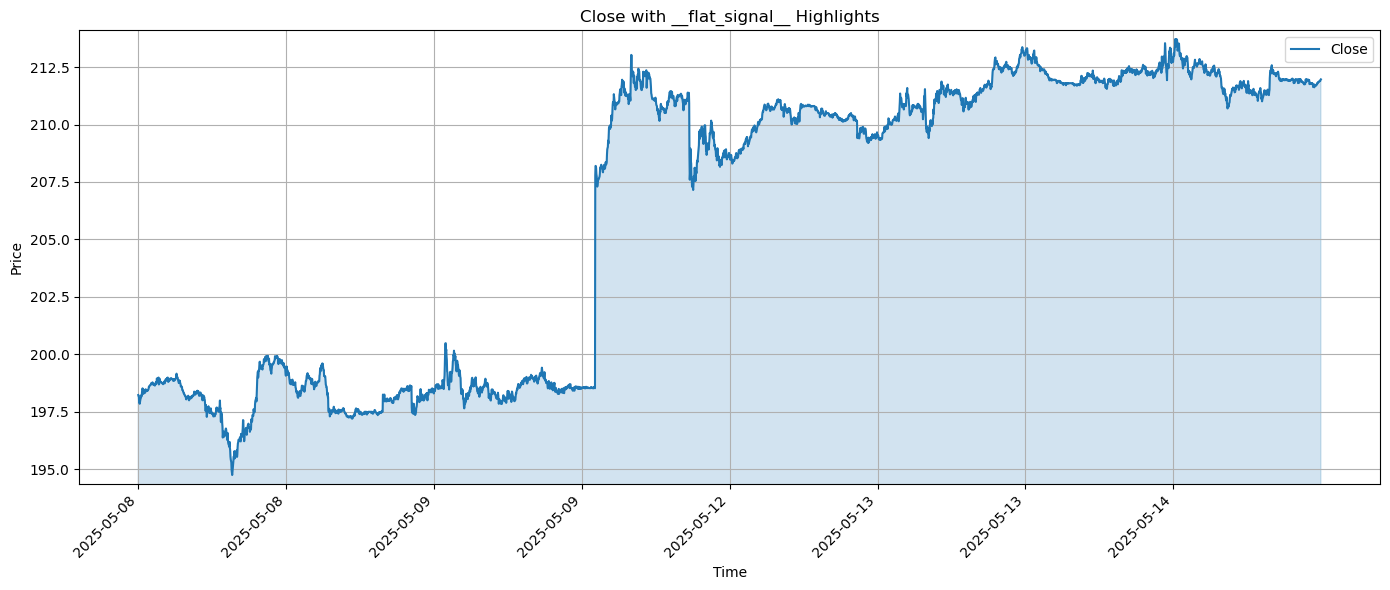

In [3]:
nostrat = Strategy()
nostrat.plot_price_with_signals(df)


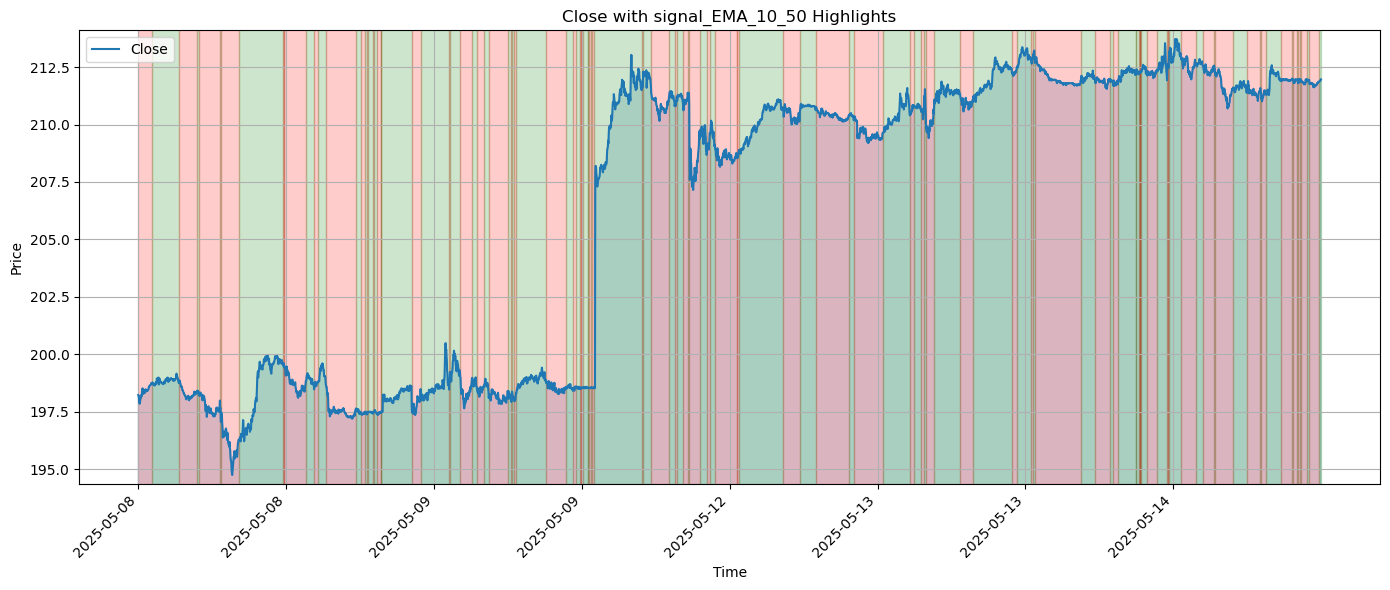

In [4]:
strategy = EMACrossoverStrategy(fast=10, slow=50)
strategy.plot_price_with_signals(df)


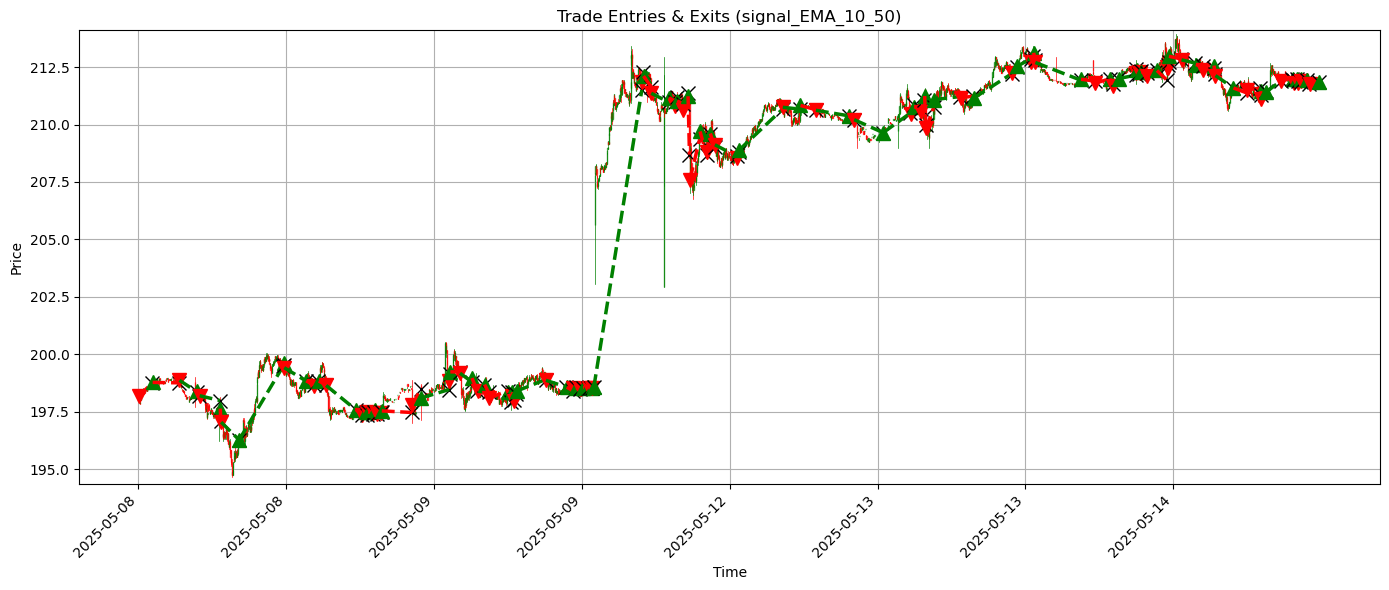

In [5]:
strategy = EMACrossoverStrategy(10, 50)
strategy.plot_trades(df)


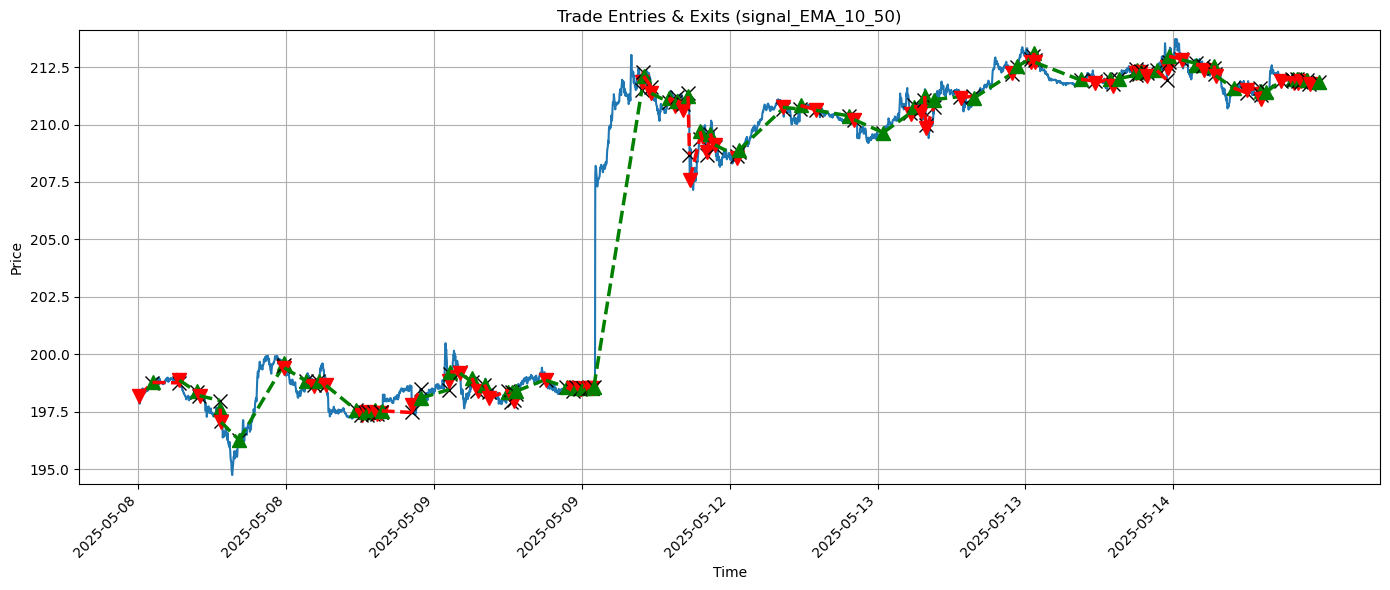

In [6]:
df=remove_hol(df)
strategy2 = EMACrossoverStrategy(10, 50)
strategy2.plot_trades(df)


In [7]:
rsi= RSIStrategy(14, 30, 70)
print(rsi.generate_signal(df))

                                     close  volume     RSI_14  \
symbol timestamp                                                
AAPL   2025-05-08 08:00:00+00:00  198.2300  7751.0        NaN   
       2025-05-08 08:01:00+00:00  198.1900  1755.0        NaN   
       2025-05-08 08:03:00+00:00  198.1900  1499.0        NaN   
       2025-05-08 08:06:00+00:00  197.9100  1606.0        NaN   
       2025-05-08 08:07:00+00:00  197.9000   521.0        NaN   
...                                    ...     ...        ...   
       2025-05-14 23:54:00+00:00  211.9000   180.0  65.624822   
       2025-05-14 23:56:00+00:00  211.8900   690.0  63.586789   
       2025-05-14 23:57:00+00:00  211.9012   586.0  64.901512   
       2025-05-14 23:58:00+00:00  211.9498  1780.0  69.968553   
       2025-05-14 23:59:00+00:00  211.9661  2176.0  71.456897   

                                  signal_RSI_14_70_30  
symbol timestamp                                       
AAPL   2025-05-08 08:00:00+00:00          

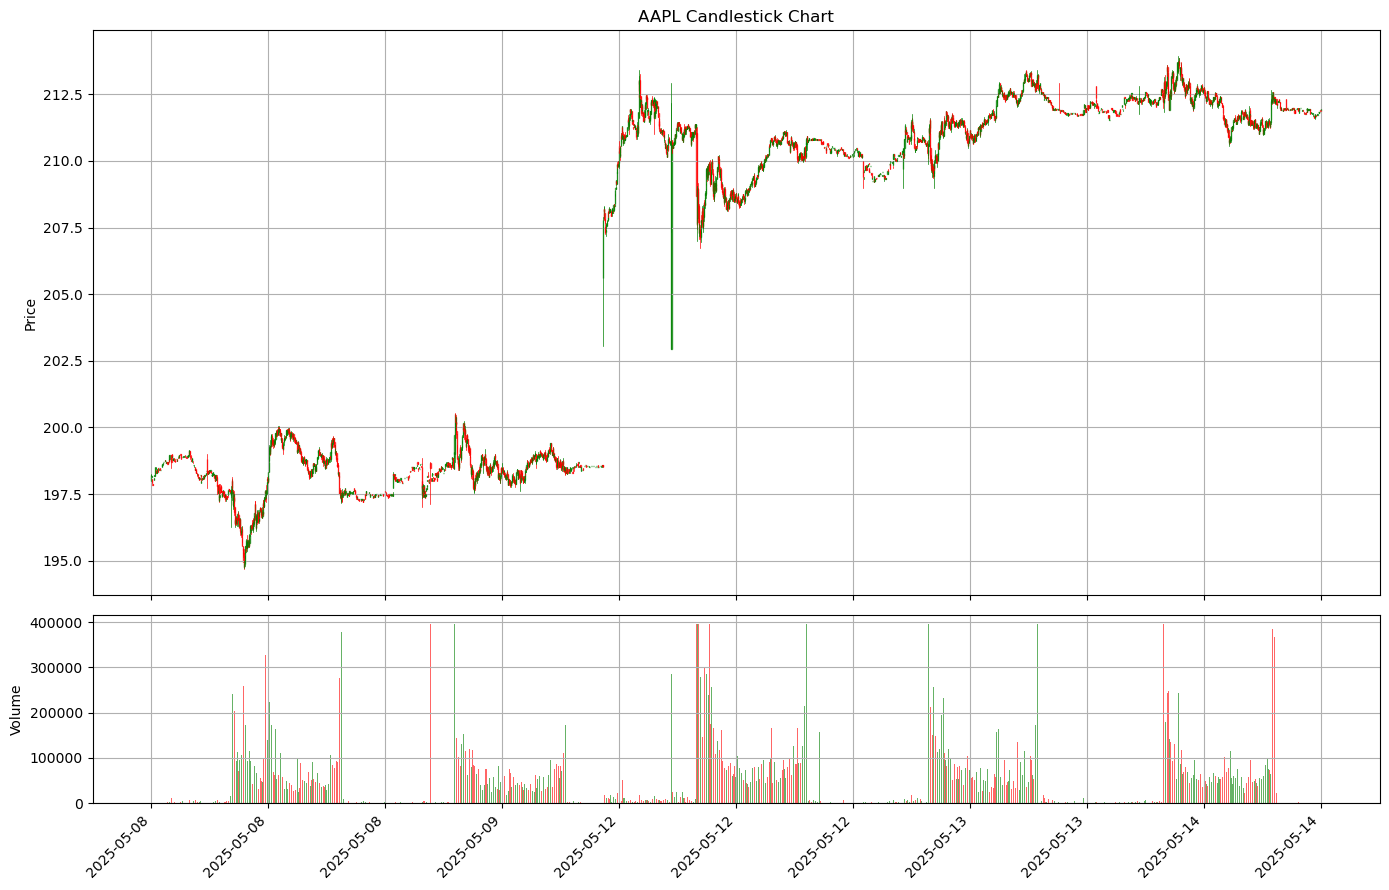

In [8]:
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)
plot_candlestick_with_volume(df, symbol)

In [9]:
print(df['volume'])


symbol  timestamp                
AAPL    2025-05-08 08:00:00+00:00    7751.0
        2025-05-08 08:01:00+00:00    1755.0
        2025-05-08 08:03:00+00:00    1499.0
        2025-05-08 08:06:00+00:00    1606.0
        2025-05-08 08:07:00+00:00     521.0
                                      ...  
        2025-05-14 23:54:00+00:00     180.0
        2025-05-14 23:56:00+00:00     690.0
        2025-05-14 23:57:00+00:00     586.0
        2025-05-14 23:58:00+00:00    1780.0
        2025-05-14 23:59:00+00:00    2176.0
Name: volume, Length: 4144, dtype: float64


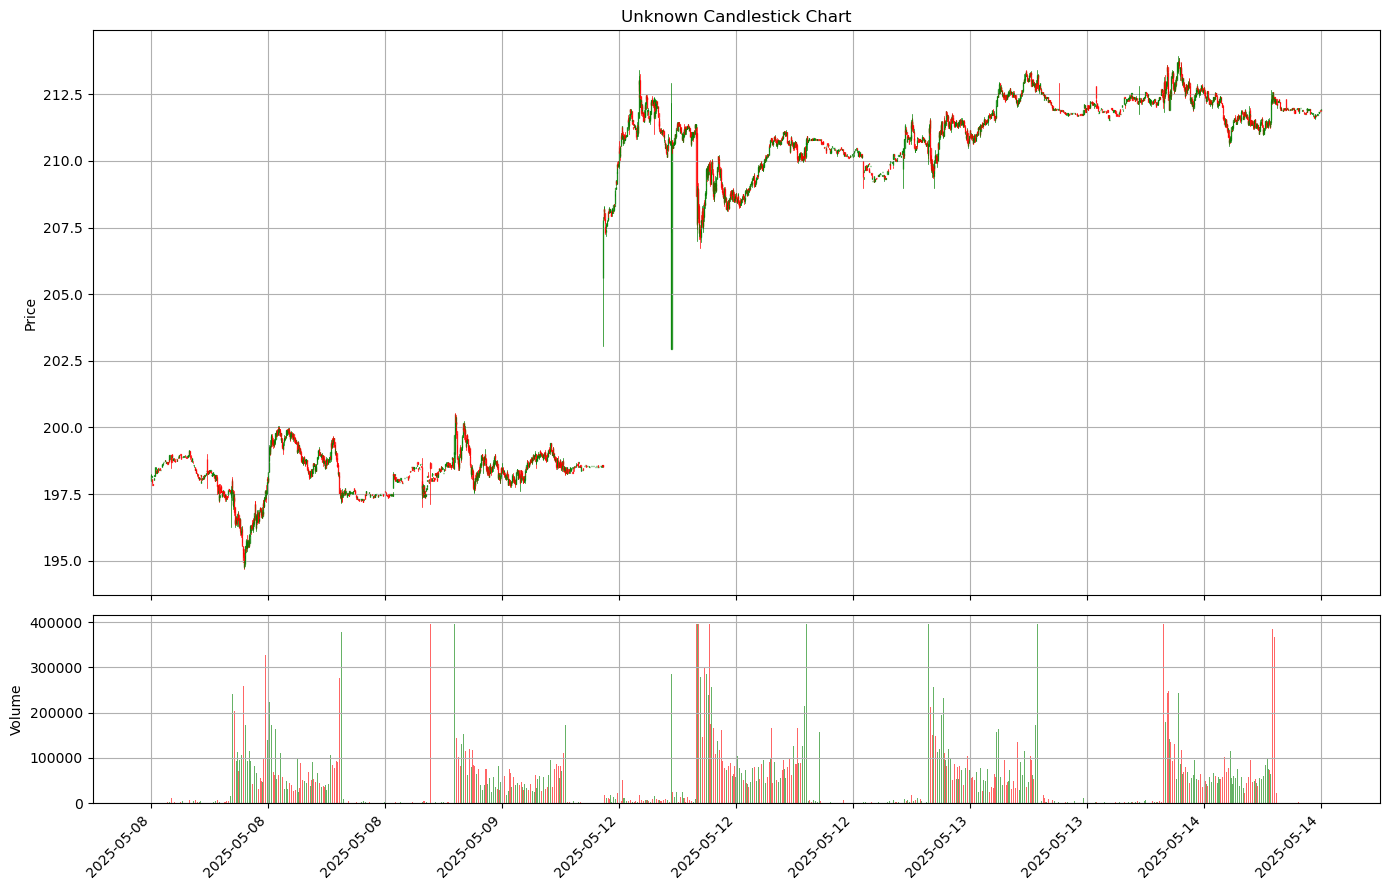

default


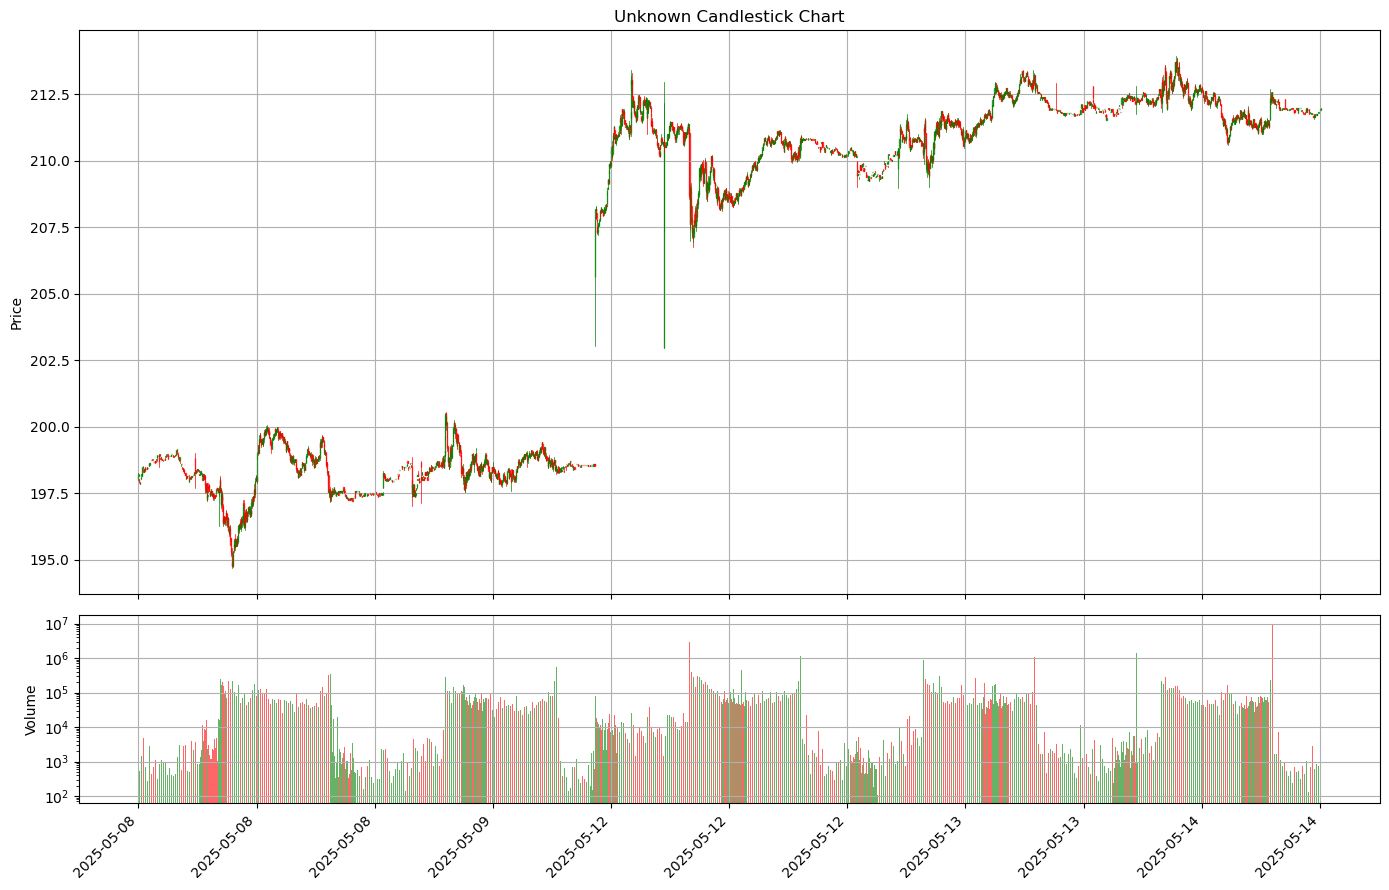

log volume = True and clip volume = False


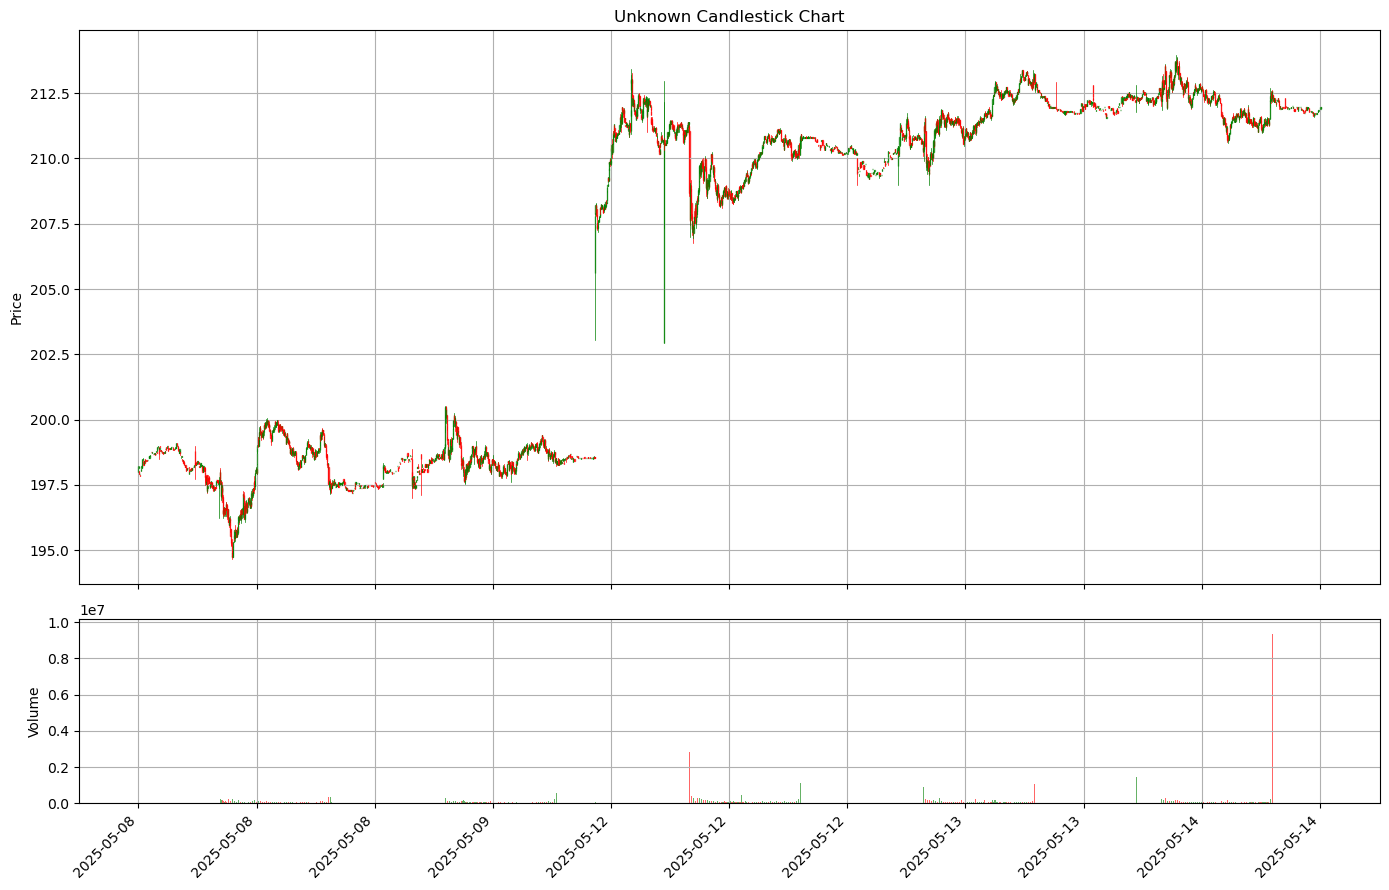

clip volume = False


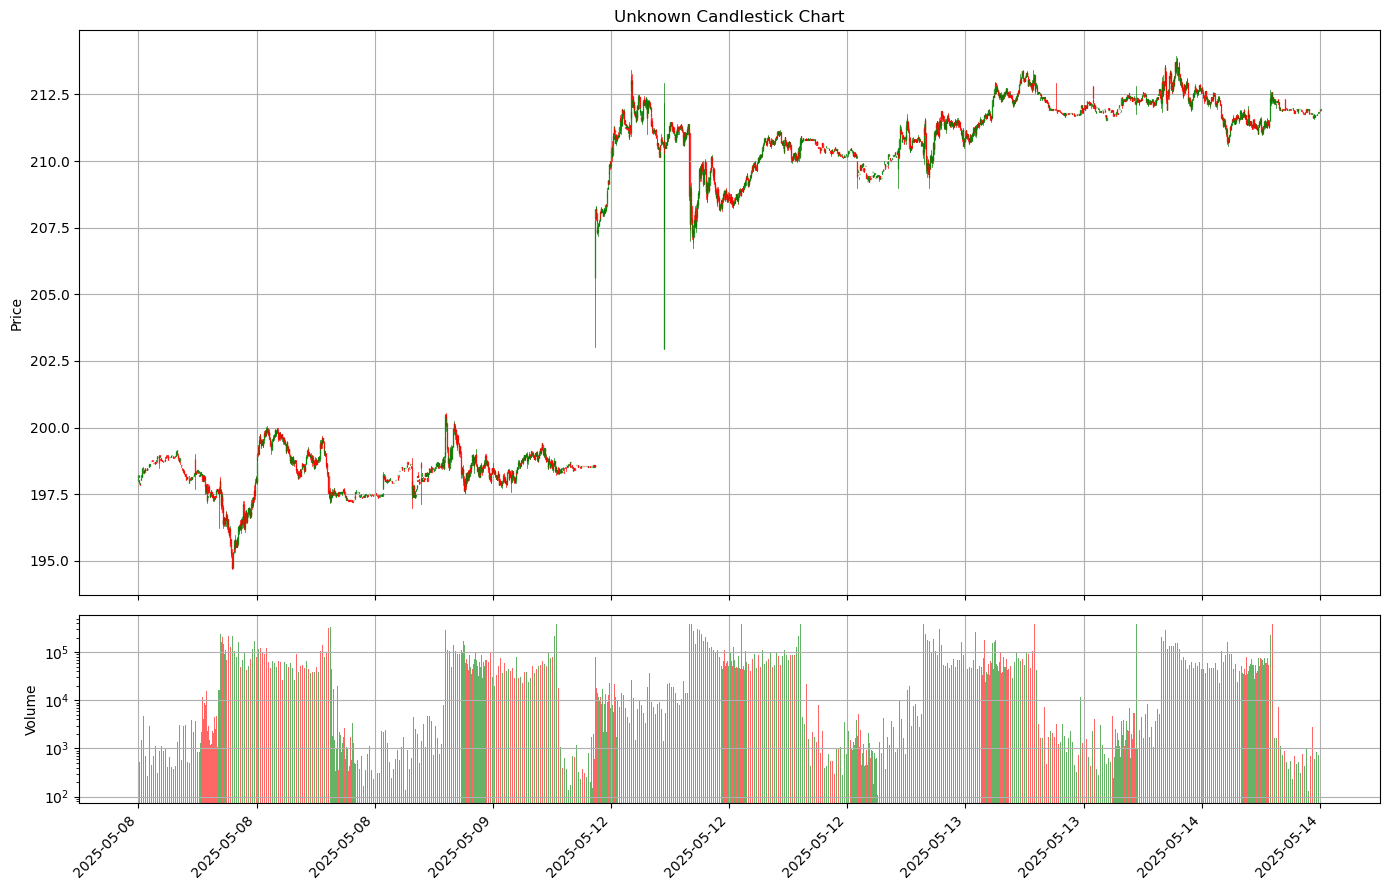

clip volume = True and log volume = True


In [10]:
# Default usage
plot_candlestick_with_volume(df)
print("default")

# Show volume with log scale
plot_candlestick_with_volume(df, use_log_volume=True, clip_volume=False)
print("log volume = True and clip volume = False")
# Show raw volume with full spikes
plot_candlestick_with_volume(df, clip_volume=False)
print("clip volume = False")
# Combine both
plot_candlestick_with_volume(df, use_log_volume=True, clip_volume=True)
print("clip volume = True and log volume = True")


In [15]:
class Backtester:
    def __init__(self, df: pd.DataFrame, signal_cols: list, initial_cash: float = 10000.0, fee_perc: float = 0.001):
        self.df = df.copy()
        self.signal_cols = signal_cols
        self.initial_cash = initial_cash
        self.fee_perc = fee_perc
        self.trade_logs = {}

    def run(self):
        for signal_col in self.signal_cols:
            trades = []
            capital = self.initial_cash
            position = None  # 'long', 'short', or None
            entry_price = None
            entry_time = None
            prev_signal = None

            for time, row in self.df.iterrows():
                curr_signal = row[signal_col]
                price = row['close']

                # Only act if signal changed
                if curr_signal == prev_signal:
                    continue

                # CLOSE logic
                if curr_signal == 0 and position is not None:
                    exit_price = price
                    exit_time = time

                    pct_return = (exit_price - entry_price) / entry_price if position == 'long' else (entry_price - exit_price) / entry_price
                    fee = self.fee_perc * 2  # entry + exit
                    net_return = pct_return - fee
                    pnl = capital * net_return
                    capital += pnl

                    trades.append({
                        'entry_time': entry_time,
                        'exit_time': exit_time,
                        'entry_price': entry_price,
                        'exit_price': exit_price,
                        'pct_return': net_return,
                        'pnl': pnl,
                        'capital': capital,
                        'type': position,
                        'signal_name': signal_col
                    })

                    position = None
                    entry_price = None
                    entry_time = None

                # OPEN logic
                elif curr_signal == 1 and position is None:
                    position = 'long'
                    entry_price = price
                    entry_time = time

                elif curr_signal == -1 and position is None:
                    position = 'short'
                    entry_price = price
                    entry_time = time

                prev_signal = curr_signal

            self.trade_logs[f"signal_trades_{signal_col}"] = pd.DataFrame(trades)

    def plot_equity(self, signal_col_name):
        key = f"equity_curve_{signal_col_name}"
        if key not in self.trade_logs:
            raise ValueError(f"No equity curve found for signal column: {signal_col_name}")

        equity_df = self.trade_logs[key]
        plt.figure(figsize=(12, 6))
        plt.plot(equity_df.index, equity_df['capital'], label='Equity Curve')
        plt.title(f"Equity Curve for {signal_col_name}")
        plt.xlabel("Time")
        plt.ylabel("Capital")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [19]:
class Backtester:
    def __init__(self, df: pd.DataFrame, signal_cols: list, initial_cash: float = 10000.0, fee_perc: float = 0.001):
        self.df = df.copy()
        self.signal_cols = signal_cols
        self.initial_cash = initial_cash
        self.fee_perc = fee_perc
        self.trade_logs = {}

    def run(self):
        for signal_col in self.signal_cols:
            trades = []
            capital = self.initial_cash
            position = None
            entry_price = None
            entry_time = None
            prev_signal = None

            for time, row in self.df.iterrows():
                curr_signal = row[signal_col]
                price = row['close']

                # Only act if signal changed
                if curr_signal == prev_signal:
                    continue

                # CLOSE logic
                if curr_signal == 0 and position is not None:
                    exit_price = price
                    exit_time = time

                    pct_return = (exit_price - entry_price) / entry_price if position == 'long' else (entry_price - exit_price) / entry_price
                    fee = self.fee_perc * 2  # entry + exit
                    net_return = pct_return - fee
                    pnl = capital * net_return
                    capital += pnl

                    trades.append({
                        'entry_time': entry_time,
                        'exit_time': exit_time,
                        'entry_price': entry_price,
                        'exit_price': exit_price,
                        'pct_return': net_return,
                        'pnl': pnl,
                        'capital': capital,
                        'type': position,
                        'signal_name': signal_col
                    })

                    position = None
                    entry_price = None
                    entry_time = None

                # OPEN logic
                elif curr_signal == 1 and position is None:
                    position = 'long'
                    entry_price = price
                    entry_time = time

                elif curr_signal == -1 and position is None:
                    position = 'short'
                    entry_price = price
                    entry_time = time

                prev_signal = curr_signal

            self.trade_logs[f"signal_trades_{signal_col}"] = pd.DataFrame(trades)

    def plot_equity(self, signal_col_name):
        key = f"signal_trades_{signal_col_name}"
        trade_log = self.trade_logs.get(key)
        if trade_log is None or trade_log.empty:
            print(f"No trades to plot for signal column: {signal_col_name}")
            return

        equity_df = trade_log[['exit_time', 'capital']].copy()
        equity_df.set_index('exit_time', inplace=True)

        plt.figure(figsize=(12, 6))
        plt.plot(equity_df.index, equity_df['capital'], label='Equity Curve')
        plt.title(f"Equity Curve for {signal_col_name}")
        plt.xlabel("Time")
        plt.ylabel("Capital")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class BacktesterV2:
    def __init__(self, df: pd.DataFrame, signal_cols: list, initial_cash: float = 100, fee_perc: float = 0.001):
        self.df = df.copy()
        self.signal_cols = signal_cols
        self.initial_cash = initial_cash
        self.fee_perc = fee_perc
        self.trade_logs = {}

    def run(self):
        for signal_col in self.signal_cols:
            trades = []
            capital = self.initial_cash
            position = None  # 'long' or 'short'
            entry_price = None
            entry_time = None
            entry_capital = None
            prev_signal = None

            equity_series = []

            for raw_index, row in self.df.iterrows():
                time = raw_index if not isinstance(raw_index, tuple) else raw_index[-1]
                curr_signal = row[signal_col].item()
                price = row['close']

                # Update equity based on unrealized PnL if in position
                if position == 'long':
                    unrealized = (price - entry_price) / entry_price
                    current_equity = entry_capital * (1 + unrealized)
                elif position == 'short':
                    unrealized = (entry_price - price) / entry_price
                    current_equity = entry_capital * (1 + unrealized)
                else:
                    current_equity = capital

                equity_series.append((time, current_equity))

                # Skip redundant signals for performance
                if curr_signal == prev_signal:
                    continue

                # CLOSE logic
                if curr_signal == 0 and position is not None:
                    exit_price = price
                    exit_time = time

                    pct_return = (exit_price - entry_price) / entry_price if position == 'long' else (entry_price - exit_price) / entry_price
                    fee = self.fee_perc * 2  # entry + exit
                    net_return = pct_return - fee
                    pnl = entry_capital * net_return
                    capital += pnl

                    capital += pnl

                    trades.append({
                        'entry_time': entry_time,
                        'exit_time': exit_time,
                        'entry_price': entry_price,
                        'exit_price': exit_price,
                        'pct_return': net_return,
                        'pnl': pnl,
                        'capital': capital,
                        'type': position,
                        'signal_name': signal_col
                    })

                    position = None
                    entry_price = None
                    entry_time = None
                    entry_capital = None

                # OPEN logic
                elif curr_signal == 1 and position is None:
                    position = 'long'
                    entry_price = price
                    entry_time = time
                    entry_capital = capital

                elif curr_signal == -1 and position is None:
                    position = 'short'
                    entry_price = price
                    entry_time = time
                    entry_capital = capital

                prev_signal = curr_signal

            # Final close logic if still in a position
            if position is not None:
                exit_price = self.df['close'].iloc[-1]
                exit_time = self.df.index[-1]

                pct_return = (exit_price - entry_price) / entry_price if position == 'long' else (entry_price - exit_price) / entry_price
                fee = self.fee_perc * 2
                net_return = pct_return - fee
                pnl = entry_capital * net_return
                capital += pnl

                trades.append({
                    'entry_time': entry_time,
                    'exit_time': exit_time,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'pct_return': net_return,
                    'pnl': pnl,
                    'capital': capital,
                    'type': position,
                    'signal_name': signal_col
                })

            self.trade_logs[f"signal_trades_{signal_col}"] = pd.DataFrame(trades)
            self.trade_logs[f"equity_curve_{signal_col}"] = pd.DataFrame(equity_series, columns=['time', 'equity']).set_index('time')

    def plot_equity(self, signal_col_name):
        key = f"equity_curve_{signal_col_name}"
        if key not in self.trade_logs:
            raise ValueError(f"No equity curve found for signal column: {signal_col_name}")

        equity_df = self.trade_logs[key]
        plt.figure(figsize=(12, 6))
        plt.plot(equity_df.index, equity_df['equity'], label='Equity Curve')
        plt.title(f"Equity Curve for {signal_col_name}")
        plt.xlabel("Time")
        plt.ylabel("Capital")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


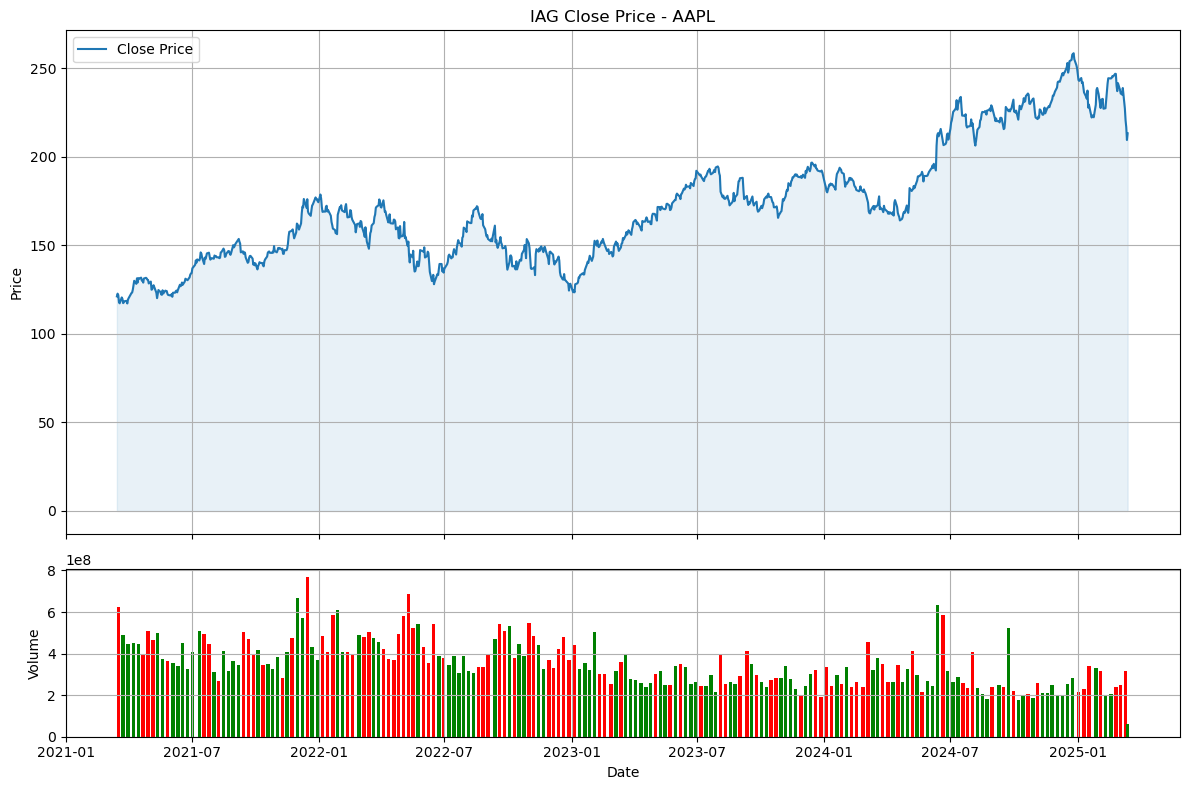

In [48]:
from typing import Optional, List


class DataHandler:
    def __init__(self, ticker: str, start: str, end: str):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.data = None

    def download_data(self) -> pd.DataFrame:
        self.data = yf.download(self.ticker, start=self.start, end=self.end)
        if self.data.empty:
            raise ValueError(f"No data found for {self.ticker}")
        if isinstance(self.data.columns, pd.MultiIndex):
            self.data.columns = [col[0] for col in self.data.columns]
        return self.data

    def get_data(self, columns: Optional[List[str]] = None) -> pd.DataFrame:
        if self.data is None:
            raise ValueError("Data not downloaded yet.")
        if columns:
            return self.data[columns]
        return self.data

import matplotlib.dates as mdates
class Plotter:
    def __init__(self, data: pd.DataFrame):
        self.data = data


    def plot_price(self, title: str = "Price Chart", ticker: str = "Ticker", volume_width: int = 1):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1])

        # X-axis: convert dates to numerical values
        x_vals = mdates.date2num(self.data.index)

        # Top chart: Close price + filled area
        close_price = self.data['Close'].values.ravel()
        ax1.plot(self.data.index, close_price, label='Close Price', color='tab:blue')
        ax1.fill_between(self.data.index, close_price, color='tab:blue', alpha=0.1)  # Area under line
        ax1.set_title(f"{title} - {ticker}")
        ax1.set_ylabel("Price")
        ax1.legend()
        ax1.grid(True)

        # --- Bottom chart: Adjusted volume bars ---
        df = self.data.copy().reset_index()
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
    
        # Group every N rows (N = volume_width)
        group_indices = df.index // volume_width
        grouped = df.groupby(group_indices).agg({
            'Date': lambda x: x.iloc[len(x) // 2],  # use middle date of the group for centering
            'Open': 'first',
            'Close': 'last',
            'Volume': 'sum'
        })
    
        # Bar properties
        x_vals = mdates.date2num(grouped['Date'])
        volume = grouped['Volume'].to_numpy()
        open_ = grouped['Open'].to_numpy()
        close = grouped['Close'].to_numpy()
    
        # Color logic
        colors = np.where(close > open_, 'green', np.where(close < open_, 'red', 'gray'))
    
        # Compute dynamic bar width based on actual time gaps
        if len(x_vals) > 1:
            avg_gap = np.mean(np.diff(x_vals))  # average days between bar centers
        else:
            avg_gap = volume_width  # fallback for single bar
        
        # Plot volume bars with dynamic width to eliminate gaps
        ax2.bar(x_vals, volume, color=colors, width=volume_width, align='center')

        ax2.set_ylabel("Volume")
        ax2.grid(True)
    
        # Format x-axis
        ax2.xaxis_date()
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.xlabel("Date")
        plt.tight_layout()
        plt.show()

    def plot_signals(
        self,
        signal_obj,
        title: str = "Signal Plot",
        highlight: bool = True,
        plot_indicators: bool = False
    ):

        if not hasattr(signal_obj, 'signals'):
            raise TypeError("signal_obj must implement a .signals() method.")

        # Pull signals
        signals = signal_obj.signals()
        df = self.data.copy()
        df['Signal'] = signals['Signal']

        plt.figure(figsize=(14, 6))
        plt.plot(df['Close'], label='Close Price', alpha=0.8)

        # Optional: plot SMA or other overlays
        if plot_indicators and hasattr(signal_obj, 'get_indicators_to_plot'):
            indicators = signal_obj.get_indicators_to_plot()
            for label, col in indicators.items():
                indicator_data = getattr(signal_obj, 'data', self.data)
                if col in indicator_data.columns:
                    plt.plot(indicator_data[col], label=label, linestyle='--', alpha=0.7)


        # Optional: highlight long/short zones
        if highlight:
            in_position = False
            entry_idx = None
            current_signal = None

            for i in range(1, len(df)):
                prev = df['Signal'].iloc[i - 1]
                curr = df['Signal'].iloc[i]

                if not in_position and curr != 0:
                    entry_idx = df.index[i]
                    current_signal = curr
                    in_position = True

                elif in_position and (curr != current_signal or curr == 0):
                    exit_idx = df.index[i]
                    color = 'green' if current_signal == 1 else 'red'
                    plt.axvspan(entry_idx, exit_idx, color=color, alpha=0.2)
                    in_position = False
                    current_signal = None

            if in_position:
                color = 'green' if current_signal == 1 else 'red'
                plt.axvspan(entry_idx, df.index[-1], color=color, alpha=0.2)

        plt.title(title)
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Plotting apple ticker example
data_handler = DataHandler(ticker="AAPL", start="2021-03-15", end="2025-03-15") #year-day-month IAG.L
data = data_handler.download_data()

plotter = Plotter(data)
plotter.plot_price(title="IAG Close Price", ticker="AAPL", volume_width=5) #5 and 7 approximate yahoo finance 

In [55]:
import yfinance as yf
import pandas as pd

def get_stock_data_yf(
    symbol: str,
    start_date: str,
    end_date: str,
    interval: str = "1d"
) -> pd.DataFrame:
    """
    Download and format Yahoo Finance data.
    
    Parameters:
        symbol (str): Ticker symbol
        start_date (str): Format 'YYYY-MM-DD'
        end_date (str): Format 'YYYY-MM-DD'
        interval (str): '1d', '1h', '1wk', etc.

    Returns:
        DataFrame with ['open', 'high', 'low', 'close', 'volume'], datetime index
    """
    df = yf.download(symbol, start=start_date, end=end_date, interval=interval)
    if df.empty:
        raise ValueError(f"No data found for {symbol} from {start_date} to {end_date}")

    df = df.rename(columns={
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Volume': 'volume'
    })[['open', 'high', 'low', 'close', 'volume']]

    df.dropna(inplace=True)
    df.index = pd.to_datetime(df.index)
    return df


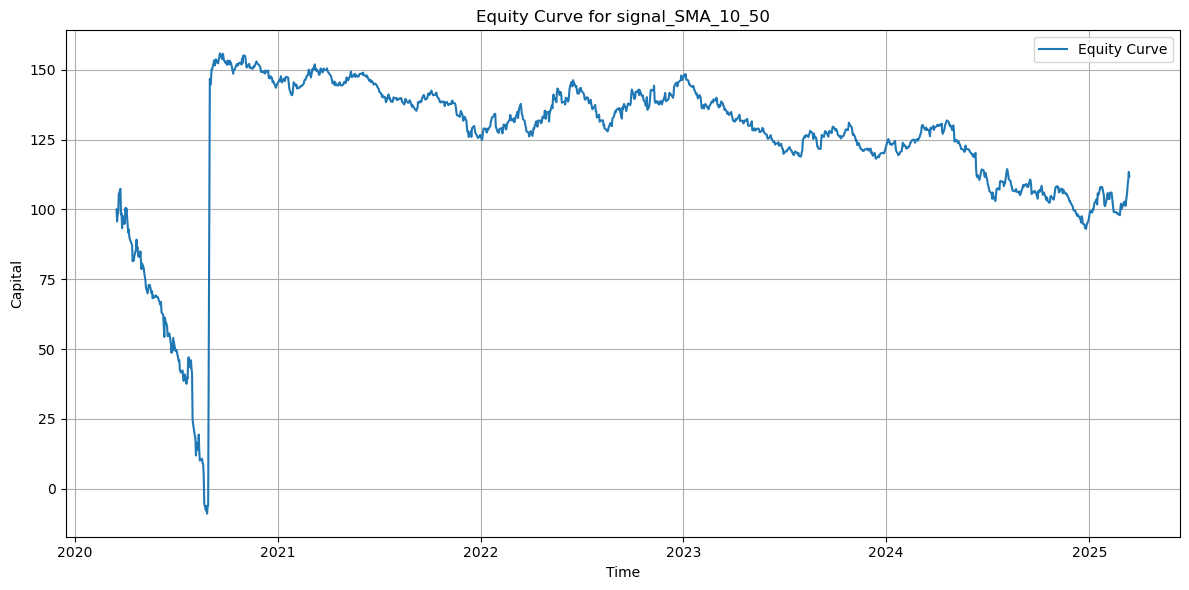

,entry_time,exit_time,entry_price,exit_price,pct_return,pnl,capital,type,signal_name
0,2020-03-16 04:00:00+00:00,"(AAPL, 2025-03-14 04:00:00+00:00)",242.21,213.49,0.116575,11.657479,111.657479,short,signal_SMA_10_50


In [62]:


df = get_stock_data("AAPL", start_date="2020-03-15", end_date="2025-03-15")

sma_strategy = SMACrossoverStrategy(fast=10, slow=50)
df = sma_strategy.generate_signal(df)
signal_name = sma_strategy.signal_col  # e.g., 'signal_SMA_10_50'


bt = BacktesterV2(df, signal_cols=[signal_name], initial_cash=100, fee_perc=0.001)
bt.run()

bt.plot_equity(signal_name)
bt.trade_logs[f"signal_trades_{signal_name}"].head()




[*********************100%***********************]  1 of 1 completed
c:\Users\narut\anaconda3\Lib\site-packages\matplotlib\cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


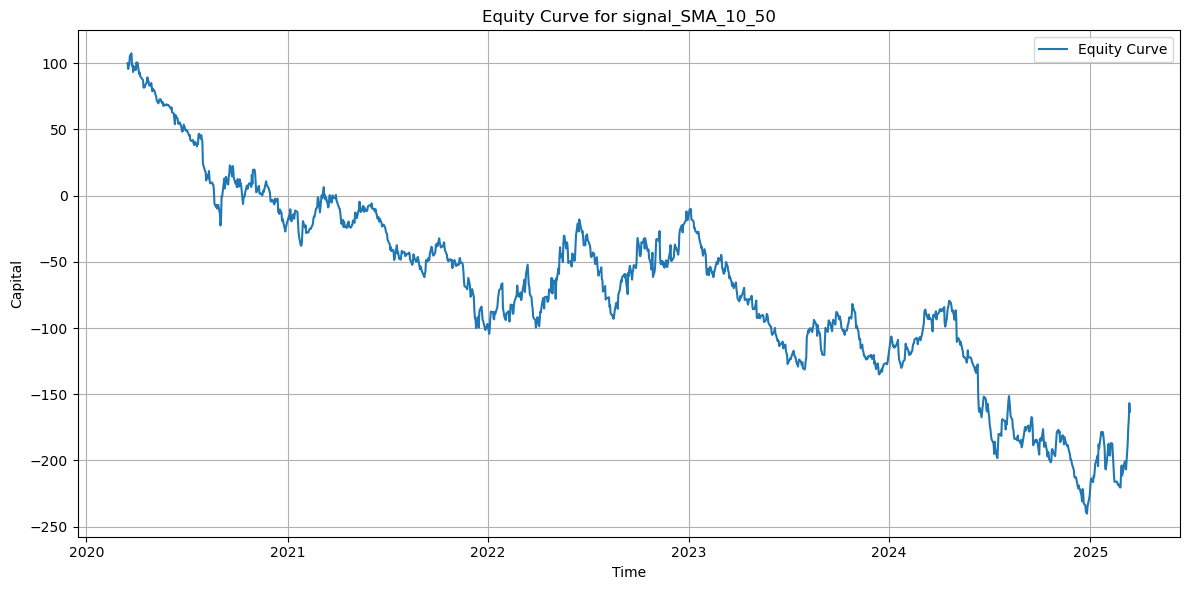

,entry_time,exit_time,entry_price,exit_price,pct_return,pnl,capital,type,signal_name
0,2020-03-16,2025-03-14,Ticker AAPL 58.702305 Name: 2020-03-16 00:0...,Ticker AAPL 213.210419 Name: 2025-03-14 00:...,Ticker AAPL -2.632062 dtype: object,Ticker AAPL -263.143007 dtype: object,Ticker AAPL -163.143007 dtype: object,short,signal_SMA_10_50


In [71]:


df = get_stock_data_yf("AAPL", start_date="2020-03-15", end_date="2025-03-15")

sma_strategy = SMACrossoverStrategy(fast=10, slow=50)
df = sma_strategy.generate_signal(df)
signal_name = sma_strategy.signal_col  # e.g., 'signal_SMA_10_50'


bt = BacktesterV2(df, signal_cols=[signal_name], initial_cash=100, fee_perc=0.001)
bt.run()

bt.plot_equity(signal_name)
bt.trade_logs[f"signal_trades_{signal_name}"].head()




In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class BacktesterV2:
    def __init__(self, df: pd.DataFrame, signal_cols, initial_cash: float = 10000.0, fee_perc: float = 0.001):
        self.df = df.copy()
        if isinstance(signal_cols, str):
            self.signal_cols = [signal_cols]
        else:
            self.signal_cols = signal_cols
        self.initial_cash = initial_cash
        self.fee_perc = fee_perc
        self.trade_logs = {}

    def run(self):
        for signal_col in self.signal_cols:
            trades = []
            capital = self.initial_cash
            position = None  # 'long' or 'short'
            entry_price = None
            entry_time = None
            entry_capital = None
            prev_signal = None
            trading_active = True

            equity_series = []

            for raw_index, row in self.df.iterrows():
                time = raw_index if not isinstance(raw_index, tuple) else raw_index[-1]
                curr_signal = row[signal_col]
                if isinstance(curr_signal, (pd.Series, np.ndarray)):
                    curr_signal = curr_signal.item()
                if pd.isna(curr_signal):
                    curr_signal = 0
                else:
                    curr_signal = int(curr_signal)

                price = row['close']

                # Update equity based on unrealized PnL if in position
                if position == 'long':
                    unrealized = (price - entry_price) / entry_price
                    current_equity = entry_capital * (1 + unrealized)
                elif position == 'short':
                    unrealized = (entry_price - price) / entry_price
                    current_equity = entry_capital * (1 + unrealized)
                else:
                    current_equity = capital

                equity_series.append((time, current_equity))

                # Skip redundant signals for performance
                if curr_signal == prev_signal:
                    continue

                if not trading_active:
                    continue

                # CLOSE logic
                if curr_signal == 0 and position is not None:
                    exit_price = price
                    exit_time = time

                    raw_return = (exit_price - entry_price) / entry_price if position == 'long' else (entry_price - exit_price) / entry_price
                    gross_pnl = entry_capital * raw_return
                    entry_fee = entry_capital * self.fee_perc
                    exit_fee = (entry_capital + gross_pnl) * self.fee_perc
                    net_pnl = gross_pnl - entry_fee - exit_fee
                    capital += net_pnl

                    trades.append({
                        'entry_time': entry_time,
                        'exit_time': exit_time,
                        'entry_price': entry_price,
                        'exit_price': exit_price,
                        'pct_return': raw_return,
                        'pnl': net_pnl,
                        'capital': capital,
                        'type': position,
                        'signal_name': signal_col
                    })

                    position = None
                    entry_price = None
                    entry_time = None
                    entry_capital = None

                    if capital <= 0:
                        trading_active = False
                        break

                # OPEN logic
                elif curr_signal == 1 and position is None and capital > 0:
                    position = 'long'
                    entry_price = price
                    entry_time = time
                    entry_capital = capital

                elif curr_signal == -1 and position is None and capital > 0:
                    position = 'short'
                    entry_price = price
                    entry_time = time
                    entry_capital = capital

                prev_signal = curr_signal

            # Final close logic if still in a position
            if trading_active and position is not None:
                exit_price = self.df['close'].iloc[-1]
                exit_time = self.df.index[-1]

                raw_return = (exit_price - entry_price) / entry_price if position == 'long' else (entry_price - exit_price) / entry_price
                gross_pnl = entry_capital * raw_return
                entry_fee = entry_capital * self.fee_perc
                exit_fee = (entry_capital + gross_pnl) * self.fee_perc
                net_pnl = gross_pnl - entry_fee - exit_fee
                capital += net_pnl

                trades.append({
                    'entry_time': entry_time,
                    'exit_time': exit_time,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'pct_return': raw_return,
                    'pnl': net_pnl,
                    'capital': capital,
                    'type': position,
                    'signal_name': signal_col
                })

            # Extend equity curve with flat capital if trading is disabled
            if not trading_active:
                final_capital = capital
                for time in self.df.loc[time:].index:
                    equity_series.append((time, final_capital))

            self.trade_logs[f"signal_trades_{signal_col}"] = pd.DataFrame(trades)
            self.trade_logs[f"equity_curve_{signal_col}"] = pd.DataFrame(equity_series, columns=['time', 'equity']).set_index('time')

    def plot_equity(self, signal_col_name):
        key = f"equity_curve_{signal_col_name}"
        if key not in self.trade_logs:
            raise ValueError(f"No equity curve found for signal column: {signal_col_name}")

        equity_df = self.trade_logs[key]
        plt.figure(figsize=(12, 6))
        plt.plot(equity_df.index, equity_df['equity'], label='Equity Curve')
        plt.title(f"Equity Curve for {signal_col_name}")
        plt.xlabel("Time")
        plt.ylabel("Capital")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

class BacktesterV2:
    def __init__(self, initial_equity=10000.0, transaction_cost=0.002):
        self.initial_equity = initial_equity
        self.transaction_cost = transaction_cost  # combined slippage + fees
        self.trades = []

    def run(self, df, signal_col="signal"):
        self.trade_log = []
        self.final_equity = self.initial_equity

        equity = self.initial_equity
        position = 0.0  # current exposure [-1 to 1]
        entry_price = None

        for timestamp, row in df.iterrows():
            price = row["close"]
            signal = float(row[signal_col])

            if equity <= 0:
                self.trade_log.append((timestamp, equity))
                continue

            # Position change
            delta = signal - position
            if delta != 0:
                notional_change = abs(delta) * equity
                trade_type = "long" if delta > 0 else "short"

                # Calculate PnL on position change
                if position != 0:
                    # Close part or all of the current position
                    pnl = (price - entry_price) * position * equity
                    pnl -= abs(position) * equity * self.transaction_cost
                    equity += pnl

                # Log the trade
                print(f"TRADE | {trade_type.upper()} | Entry: {price:.2f}, Exit: {price:.2f}, PnL: {pnl:.2f}, Equity: {equity:.2f}")

                # Update
                position = signal
                entry_price = price

            self.trade_log.append((timestamp, equity))

        self.final_equity = equity



    def get_trade_log(self):
        return pd.DataFrame(self.trades)
    
    def reset(self):
        self.trade_log = []
        self.final_equity = self.initial_equity


    def plot_equity(self):
        df = self.get_trade_log()
        if df.empty:
            print("No trades to plot.")
            return

        df = df.sort_values('exit_time')
        plt.figure(figsize=(12, 6))
        plt.plot(df['exit_time'], df['equity_after'], marker='o', linestyle='-', color='blue')
        plt.title('Equity Curve')
        plt.xlabel('Time')
        plt.ylabel('Equity')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [100]:
print(df.columns)


Index(['open', 'high', 'low', 'close', 'volume', 'SMA_10', 'SMA_50',
       'signal_SMA_10_50'],
      dtype='object')


In [108]:
# Step 1: Get the data
df = get_stock_data_yf("AAPL", start_date="2020-03-15", end_date="2025-03-15")
df = get_stock_data("AAPL", start_date="2020-03-15", end_date="2025-03-15")

#plot_candlestick_with_volume(df)

# Step 2: Apply a strategy (e.g., SMA crossover)
strategy = SMACrossoverStrategy(fast=10, slow=50)
df = strategy.generate_signal(df)

# Step 3: Run the backtest
backtester = BacktesterV2()
backtester.run(df, signal_col=strategy.signal_col)

# Step 4: Plot equity curve
backtester.plot_equity()

[*********************100%***********************]  1 of 1 completed


UnboundLocalError: cannot access local variable 'pnl' where it is not associated with a value

In [82]:
print(f"Total trades: {len(backtester.get_trade_log())}")


Total trades: 1
